In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  
# Set the float display format to scientific notation
pd.set_option('display.float_format', '{:.2e}'.format)
# pd.set_option('display.float_format', '{:.2f}'.format)
# pd.set_option('display.precision', 2)

import yaml

In [3]:
from library.utils import fontstyle, style_map
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

In [4]:
from library.cables import PHL_Mn_4K, R_Manganin_4K
from library.components import SIS_OHMIC_RESISTOR, SIS_current_split


def SISv1_heat_loads(num_LO_pair=1):
    # Active Load
    current = 22E-3 
    AHL = current * 368.068E-6 # equivalent volts for same power of 8.1 uW
    
    
    # Ohmic Load
    current_list = SIS_current_split(current, num_LO_pair)
    
    resistance = R_Manganin_4K
    ohmic_resistor = SIS_OHMIC_RESISTOR(resistance, current_list, "SIS_ohmic_resistor")
    OHL = ohmic_resistor.power_dissipation()
    
    
    # Passive Load
    num_wires = 2* num_LO_pair + 3 
    PHL = num_wires * PHL_Mn_4K

    return AHL, PHL, OHL


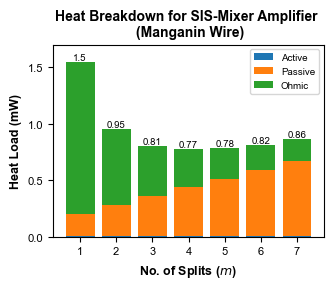

In [18]:
# Data generation
num_LO_pairs = [1,2,3,4,5,6,7]

active = []
passive = []
ohmic = []

for n in num_LO_pairs:
    AHL, PHL, OHL = SISv1_heat_loads(n)
    active.append(AHL)
    passive.append(PHL)
    ohmic.append(OHL)

active = np.array(active)*1E3
passive = np.array(passive)*1E3
ohmic = np.array(ohmic)*1E3
totals = active + passive + ohmic

# X positions
x = np.arange(len(num_LO_pairs))

# Plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5, 3))

ax.bar(x, active, label="Active")
ax.bar(x, passive, bottom=active, label="Passive")
ax.bar(x, ohmic, bottom=active + passive, label="Ohmic")

# ---- Annotate totals ----
for i in range(len(x)):
    ax.text(
        x[i],                     # x position
        totals[i],                # y position (top of stack)
        f"{totals[i]:.2}",       # formatting (scientific)
        ha='center',
        va='bottom',
        fontproperties=text_font
    )

ax.set_xticks(x)
ax.set_xticklabels(num_LO_pairs, fontproperties=tick_label_font, rotation=0)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
    
ax.set_xlabel("No. of Splits ($m$)", fontproperties=axis_label_font)
ax.set_ylabel("Heat Load (mW)", fontproperties=axis_label_font)

ax.set_ylim(0, max(totals)*1.1)

title = "Heat Breakdown for SIS-Mixer Amplifier \n (Manganin Wire)"
ax.set_title(title, fontproperties=title_font)

ax.legend(prop=text_font)

plt.tight_layout()

# Save figure
plt.savefig(f"./sis_split.png",dpi=600,bbox_inches='tight')